In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

df = pd.read_csv("business_data.csv")
df.columns = df.columns.str.strip()

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 5.6 KB


In [9]:
df[['Quantity', 'Price', 'Total_Sales']].describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


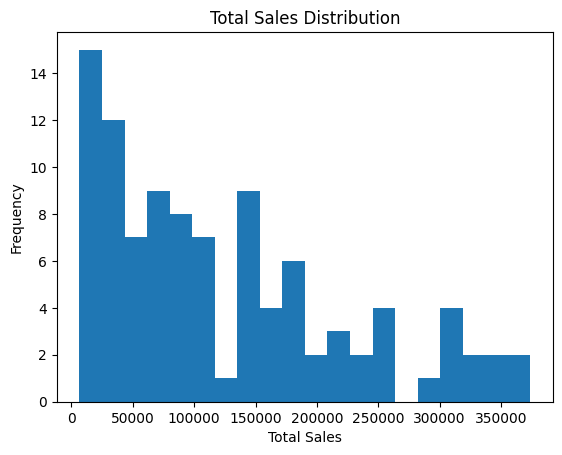

ShapiroResult(statistic=np.float64(0.8989262036779536), pvalue=np.float64(1.259076720571478e-06))

In [10]:
plt.hist(df['Total_Sales'], bins=20)
plt.title("Total Sales Distribution")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

stats.shapiro(df['Total_Sales'])


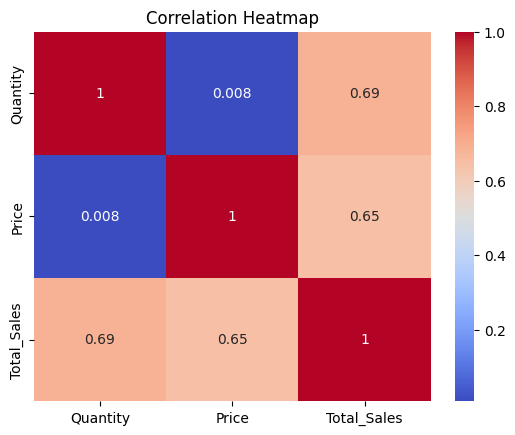

,Quantity,Price,Total_Sales
Quantity,1.000000,0.008014,0.688107
Price,0.008014,1.000000,0.646131
Total_Sales,0.688107,0.646131,1.000000


In [11]:
corr = df[['Quantity', 'Price', 'Total_Sales']].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

corr


In [12]:
regions = df['Region'].unique()
regions


<StringArray>
['East', 'North', 'West', 'South']
Length: 4, dtype: str

In [13]:
region_a = df[df['Region'] == regions[0]]['Total_Sales']
region_b = df[df['Region'] == regions[1]]['Total_Sales']

stats.ttest_ind(region_a, region_b)


TtestResult(statistic=np.float64(-0.35710677600784724), pvalue=np.float64(0.7226811638407538), df=np.float64(45.0))

In [14]:
groups = [df[df['Region'] == r]['Total_Sales'] for r in regions]
stats.f_oneway(*groups)


F_onewayResult(statistic=np.float64(2.164363429897842), pvalue=np.float64(0.09723678084979993))

In [15]:
high_qty = df[df['Quantity'] > df['Quantity'].median()]['Total_Sales']
low_qty = df[df['Quantity'] <= df['Quantity'].median()]['Total_Sales']

stats.ttest_ind(high_qty, low_qty)


TtestResult(statistic=np.float64(7.779538586652192), pvalue=np.float64(7.470163657941178e-12), df=np.float64(98.0))

In [16]:
mean = df['Total_Sales'].mean()
std = df['Total_Sales'].std()
n = len(df)

margin_error = stats.t.ppf(0.975, n-1) * (std / np.sqrt(n))
(mean - margin_error, mean + margin_error)


(np.float64(103776.34767080679), np.float64(143524.6123291932))

In [17]:
X = df[['Quantity', 'Price']]
y = df['Total_Sales']

model = LinearRegression()
model.fit(X, y)

model.score(X, y)


0.8839073148081258